In [3]:
from torchvision import transforms
from transformers import ViTForImageClassification
from transformers import AutoImageProcessor
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from time import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from ptflops import get_model_complexity_info
import seaborn as sns

In [4]:
processor=AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


# Architecture

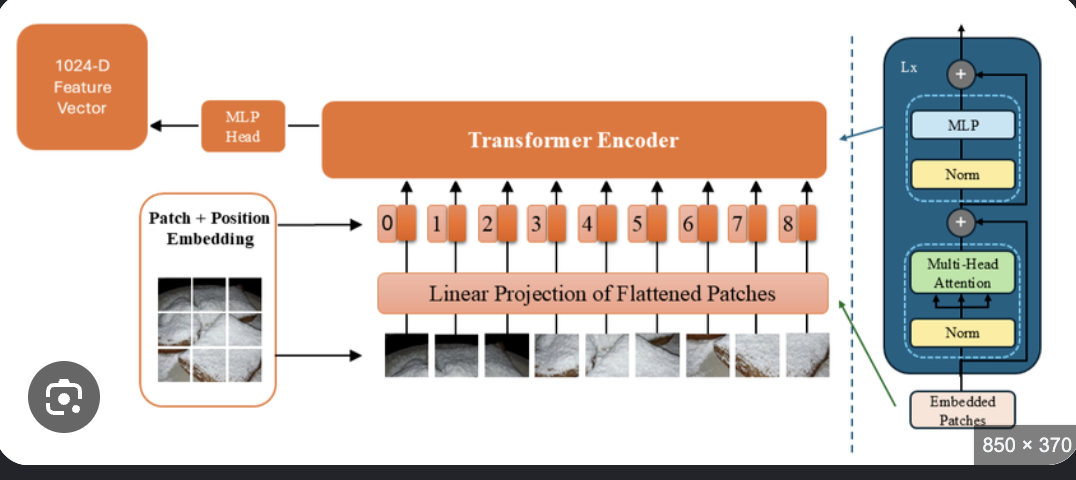

In [5]:
processor.image_mean

[0.5, 0.5, 0.5]

In [6]:
processor.image_std

[0.5, 0.5, 0.5]

## **DATA LOADING AND TRANSFORMATION, SETUP**

In [7]:
data_dir = "/kaggle/input/datasets/parth04pt/cat-dog-images/data"

In [8]:
dataset = ImageFolder(root=data_dir)

In [13]:
train_size = int(0.8 * len(dataset))

test_size = len(dataset) - train_size

train_subset, test_subset = random_split(dataset,[train_size, test_size],generator=torch.Generator().manual_seed(42))

In [14]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(

        brightness=0.2,

        contrast=0.2,

        saturation=0.2

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=processor.image_mean,

        std=processor.image_std

    )

])

In [15]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

    mean=processor.image_mean,

    std=processor.image_std

    )

])

In [16]:
train_dataset = torch.utils.data.Subset(

    ImageFolder(

        root=data_dir,

        transform=train_transform

    ),

    train_subset.indices

)

test_dataset = torch.utils.data.Subset(

    ImageFolder(

        root=data_dir,

        transform=test_transform

    ),

    test_subset.indices

)

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)
# num_workers controls how many CPU processes load images.
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

In [18]:
model= ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


### num_labels=2 replaces output size from 1000 (imagenet std) to 2

In [19]:
device= torch.device('cuda')

In [20]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [21]:
model.classifier

Linear(in_features=768, out_features=2, bias=True)

In [22]:
device

device(type='cuda')

In [23]:
model=model.to(device)

In [24]:
loss= nn.CrossEntropyLoss()
optim= AdamW(model.parameters(),lr= 2e-5,weight_decay=0.01)
scheduler = CosineAnnealingLR(optim,T_max=10)

In [25]:
epochs=10

## **TRAINING**

In [26]:
start = time()

for epoch in tqdm(range(epochs)):

    model.train()

    total = 0
    correct = 0
    epoch_loss = 0.0

    for imgs, labels in train_loader:

        imgs = imgs.to(device)

        labels = labels.to(device)

        outputs = model(imgs)

        logits= outputs.logits

        l = loss(
            logits,
            labels
        )

        optim.zero_grad()

        l.backward()

        optim.step()


        preds = torch.argmax(logits,dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        epoch_loss += l.item()

    print(
        f"Loss Epoch {epoch+1}: "
        f"{epoch_loss/len(train_loader):.4f}"
    )

    print(
        f"Accuracy Epoch {epoch+1}: "
        f"{100*correct/total:.2f}%"
    )

train_time = time() - start

  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 10%|█         | 1/10 [11:30<1:43:31, 690.16s/it]

Loss Epoch 1: 0.0435
Accuracy Epoch 1: 98.66%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 20%|██        | 2/10 [23:13<1:33:01, 697.71s/it]

Loss Epoch 2: 0.0097
Accuracy Epoch 2: 99.70%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 30%|███       | 3/10 [34:56<1:21:41, 700.15s/it]

...

Loss Epoch 8: 0.0038
Accuracy Epoch 8: 99.84%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 90%|█████████ | 9/10 [1:45:13<11:42, 702.62s/it]

Loss Epoch 9: 0.0028
Accuracy Epoch 9: 99.90%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 10/10 [1:56:55<00:00, 701.53s/it]

Loss Epoch 10: 0.0013
Accuracy Epoch 10: 99.96%


## **TESTING**

In [27]:
model.eval()

correct = 0
total = 0

LOSS = 0.0

all_preds = []
all_labels = []

start = time()

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        labels = labels.to(device)

        outputs = model(imgs)

        logits = outputs.logits

        l = loss(
            logits,
            labels
        )

        preds = torch.argmax(logits,dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        LOSS += l.item()

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.cpu().numpy().flatten()
        )

test_time = time() - start

print(
    f"Test Loss : "
    f"{LOSS/len(test_loader):.4f}"
)

print(
    f"Test Accuracy : "
    f"{100*correct/total:.2f}%"
)

print(
    f"Test Time : "
    f"{test_time:.2f}s"
)

Test Loss : 0.0132
Test Accuracy : 99.62%
Test Time : 63.14s


## custom inference
#### file path -> pil image -> tensor -> unsqueeze(0) -> pass to model

In [28]:
cls=["cat", "dog"]

In [32]:
from PIL import Image
model.eval()
dog = Image.open("/kaggle/input/datasets/parth04pt/cat-dog-infer-imgs/dog.jpeg").convert("RGB")
cat=Image.open("/kaggle/input/datasets/parth04pt/cat-dog-infer-imgs/cat.png").convert("RGB")


In [33]:
infer_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,

        std=processor.image_std
    )
])

In [34]:
cat_tensor = infer_transform(cat)
dog_tensor = infer_transform(dog)

In [36]:
start= time()
outputs1 = model(dog_tensor.unsqueeze(0).to(device))
logits1 =outputs1.logits 
# (1,2) shape
probs1= torch.softmax(logits1,dim=1)
# (1,2 ) shape
pred1=probs1.argmax(dim=1).item()
# max prob along rows
confidence1 = probs1.max().item()
infer_time1 = time()- start

In [37]:
mean = torch.tensor(

    [0.485,0.456,0.406]

)

std = torch.tensor(

    [0.229,0.224,0.225]

)

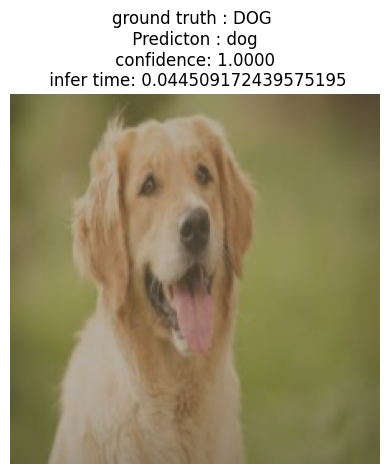

In [38]:
plt.title(f"ground truth : DOG \n Predicton : {cls[pred1]} \n confidence: {confidence1:.4f} \n infer time: {infer_time1}")
img= dog_tensor.squeeze(0).cpu()
img = img * std.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

In [40]:
start= time()
outputs2 = model(cat_tensor.unsqueeze(0).to(device))
logits2 =outputs2.logits 
# (1,2) shape
probs2= torch.softmax(logits2,dim=1)
# (1,2 ) shape
pred2=probs2.argmax(dim=1).item()
# max prob along rows
confidence2 = probs2.max().item()
infer_time2 = time()- start

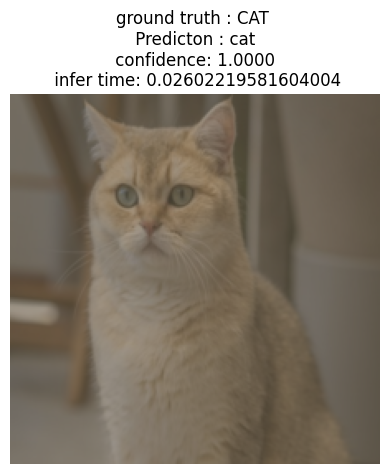

In [41]:
plt.title(f"ground truth : CAT \n Predicton : {cls[pred2]} \n confidence: {confidence2:.4f} \n infer time: {infer_time2}")
img= cat_tensor.squeeze(0).cpu()
img = img * std.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

# METRICS

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc= accuracy_score(all_labels, all_preds)
pre = precision_score(all_labels, all_preds),
rec= recall_score(all_labels, all_preds)
f1= f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

In [43]:
num_paramerters=0
num_layers=0
for p in model.parameters():
    num_layers+=1
    num_paramerters+=p.numel()
    #weights
    #bias

In [44]:
memory_usage= torch.cuda.memory_allocated()/1024**2

In [45]:
macs, params = get_model_complexity_info(model,(3,224,224),as_strings=False,print_per_layer_stat=False)

In [46]:
flops= macs*2

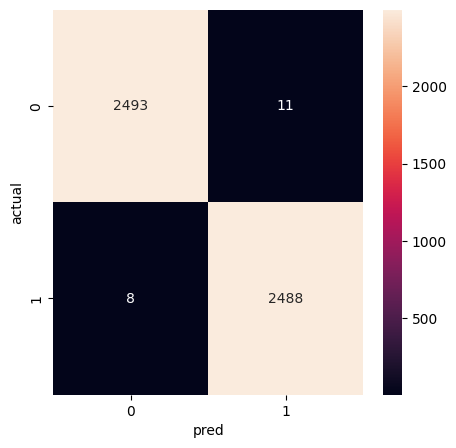

In [47]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt= 'd')
plt.xlabel("pred")
plt.ylabel("actual")
plt.show()

In [49]:
print("="*60)
print("VISION TRANSFORMER EVALUATION RESULTS")
print("="*60)

print(f"Model         : ViT-Base-Patch16-224")
print(f"Epochs        : {epochs}")

print()

print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {pre[0]:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1 Score      : {f1:.4f}")

print()

print(f"Training Time : {train_time:.2f}s")
print(f"Testing Time  : {test_time:.2f}s")

print()

print(f"Parameters    : {num_paramerters:,}")
print(f"FLOPs         : {flops:,.0f}")
print(f"Layers        : {num_layers}")
print(f"Memory Usage  : {memory_usage:.2f} MB")

print()

print("Classes       :", cls)

print()

print("Confusion Matrix")
print(cm)

print("="*60)

VISION TRANSFORMER EVALUATION RESULTS
Model         : ViT-Base-Patch16-224
Epochs        : 10

Accuracy      : 0.9962
Precision     : 0.9956
Recall        : 0.9968
F1 Score      : 0.9962

Training Time : 7015.26s
Testing Time  : 63.14s

Parameters    : 85,800,194
FLOPs         : 33,736,014,340
Layers        : 200
Memory Usage  : 1563.47 MB

Classes       : ['cat', 'dog']

Confusion Matrix
[[2493   11]
 [   8 2488]]


In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=cls
    )
)

              precision    recall  f1-score   support

         cat       1.00      1.00      1.00      2504
         dog       1.00      1.00      1.00      2496

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000

